In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Biggest predictor of CO2 output
*What is the biggest predictor of a large CO2 output per capita of a country?*

In [2]:
# Import the data files
df_co2_kaya = pd.read_csv('../data/kaya-identity-co2.csv')


#### Biggest strides in decreasing CO2 output
*Which countries are making the biggest strides in decreasing CO2 output?*

In [3]:
# Import the data files
df_co2_emissions = pd.read_csv('../data/co-emissions-per-capita.csv')

In [4]:
# Filter by year 2023
df_co2_emissions_2023 = df_co2_emissions[df_co2_emissions['Year'] == 2023]

#### Best future price for non-fossil fuel energy
*Which non-fossil fuel energy technology will have the best price in the future?*

In [5]:
# Import the data files
df_cost_energy = pd.read_csv('../data/levelized-cost-of-energy.csv')

In [6]:
# Filter by year 2023
df_cost_energy_2023 = df_cost_energy[df_cost_energy['Year'] == 2023]

In [7]:
df_cost_energy_2023.head()

,Entity,Code,Year,Bioenergy,Geothermal,Offshore wind,Solar photovoltaic,Concentrated solar power,Hydropower,Onshore wind
14,Argentina,ARG,2023,NaN,NaN,NaN,NaN,NaN,NaN,0.107900
40,Australia,AUS,2023,NaN,NaN,NaN,0.035776,NaN,NaN,0.043217
56,Austria,AUT,2023,NaN,NaN,NaN,NaN,NaN,NaN,0.047340
71,Belgium,BEL,2023,NaN,NaN,NaN,NaN,NaN,NaN,0.063638
95,Brazil,BRA,2023,NaN,NaN,NaN,0.043257,NaN,NaN,0.025133


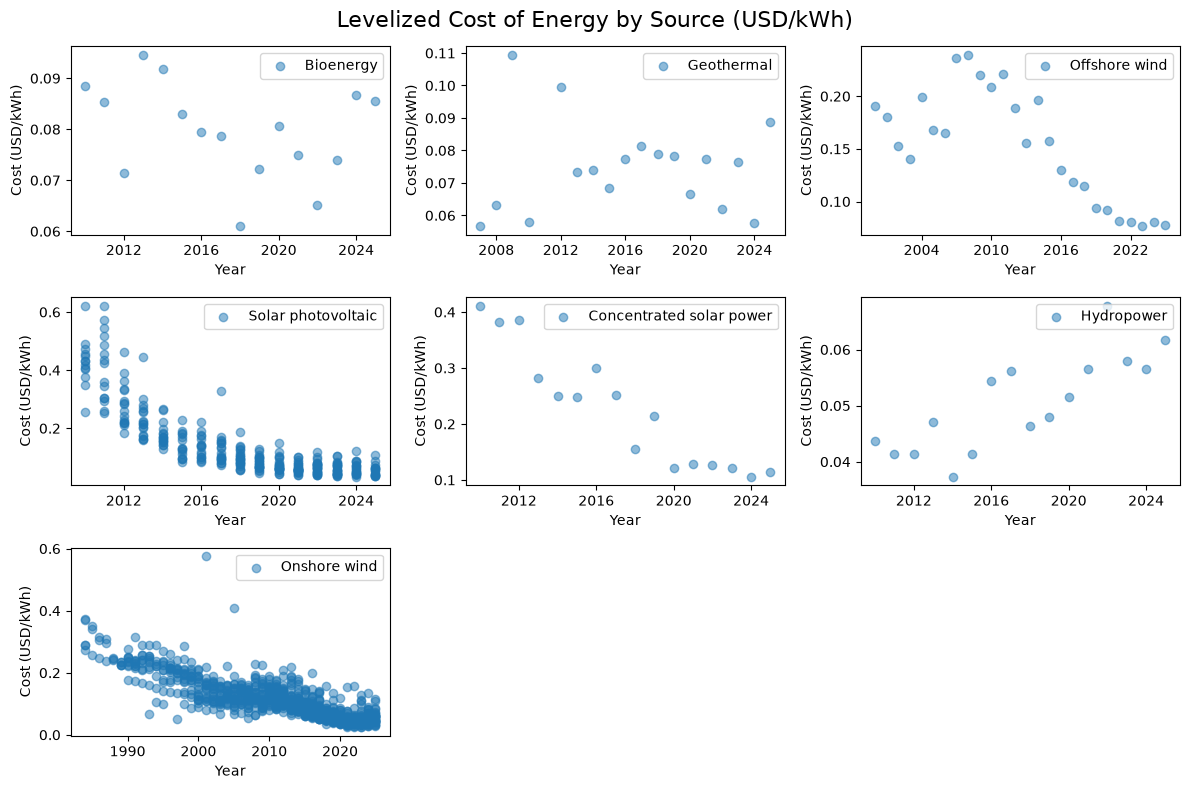

In [23]:
energy_sources = [
    "Bioenergy",
    "Geothermal",
    "Offshore wind",
    "Solar photovoltaic",
    "Concentrated solar power",
    "Hydropower",
    "Onshore wind"
]

fig, ax = plt.subplots(3, 3, figsize=(12, 8))
ax = ax.flatten()

for i, source in enumerate(energy_sources):
    data = df_cost_energy[['Year', source]].dropna()

    x = data[['Year']]
    y = data[source]
    ax[i].scatter(x, y, alpha=0.5, label=source)
    ax[i].set_xlabel('Year')
    ax[i].set_ylabel('Cost (USD/kWh)')
    ax[i].legend(loc='upper right')
    ax[i].xaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=5))

ax[8].set_visible(False)
ax[7].set_visible(False)
fig.suptitle('Levelized Cost of Energy by Source (USD/kWh)', fontsize=16)
plt.tight_layout()
